<a href="https://colab.research.google.com/github/ParusSlava/melbourne-housing/blob/main/notebook/26_06_26_melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")


Бібліотеки готові ✅


## Крок 1. Завантаження даних

In [ ]:
RAW_URL = 'https://raw.githubusercontent.com/ParusSlava/melbourne-housing/refs/heads/main/data/melb_data.csv'

df_origin = pd.read_csv(RAW_URL)

In [ ]:
df = df_origin.copy()

## Крок 2. Перший огляд

In [ ]:
print(df.shape)

(13580, 21)


In [ ]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
# Типи стовпців
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [ ]:
# пропуски: зробіть таблицю "скільки пропусків у кожному стовпці у відсотках"
df.isna().mean().round(2).sort_values(ascending=False)

,0
BuildingArea,0.47
YearBuilt,0.40
CouncilArea,0.10
Address,0.00
Suburb,0.00
Price,0.00
Type,0.00
Rooms,0.00
Method,0.00
Postcode,0.00


In [ ]:
#  описова статистика чисел
df.describe().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [ ]:
print("Кількість нулів:\n", (df == 0).sum())
print("\nКількість NaN:\n", df.isna().sum())

Кількість нулів:
 Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            6
Postcode            0
Bedroom2           16
Bathroom           34
Car              1026
Landsize         1939
BuildingArea       17
YearBuilt           0
CouncilArea         0
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

Кількість NaN:
 Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


## Крок 3. Очищення

In [ ]:
# Робимо копію (захист оригіналу)
clean = df.copy()
print('Копію створено. Розмір:', clean.shape)

Копію створено. Розмір: (13580, 21)


In [ ]:
# Перевіряємо технічний стовпець-індекс
clean = df.copy()
if 'Unnamed: 0' in df.columns:
    clean = clean.drop(columns = ['Unnamed: 0'])
    print('Column with index - deleted')


In [ ]:
# Змінюємо тип даних в Даті (конвертуємо)
clean['Date'] = pd.to_datetime(clean['Date'], dayfirst = True)

#  Після конвертації
print("Тип після:", clean["Date"].dtype)


Тип після: datetime64[ns]


In [ ]:
# Замінюємо нулі на "немає даних"

# 1. Дивимося скільки нулів у стовпцях до заміни
print("Нулів у стовпці 'Landsize'до:", (clean['Landsize'] == 0).sum())
print("Нулів у стовпці 'BuildingArea'до:", (clean['BuildingArea'] == 0).sum())

Нулів у стовпці 'Landsize'до: 1939
Нулів у стовпці 'BuildingArea'до: 17


In [ ]:
# 2. Замінюємо 0 на NaN (справжнє "немає даних")
for col in ['Landsize', 'BuildingArea']:
    clean.loc[clean[col] == 0, col] = np.nan

# 3. Дивимося скільки нулів у стовпцях після заміни
print("\nНулів у стовпці 'Landsize' Після:", (clean['Landsize'] == 0).sum())
print("Нулів у стовпці 'BuildingArea' Після:", (clean['BuildingArea'] == 0).sum())


Нулів у стовпці 'Landsize' Після: 0
Нулів у стовпці 'BuildingArea' Після: 0


In [ ]:
# Виправляємо неможливі роки побудови
# 1. Дивимося що є підозрілого
print('Мінімальний рік:', clean['YearBuilt'].min())
print('Максимальний рік:', clean['YearBuilt'].max())


Мінімальний рік: 1196.0
Максимальний рік: 2018.0


In [ ]:
# Дивимося кількість підозрілих значень
print(clean[clean['YearBuilt'] < 1800]['YearBuilt'].value_counts())

YearBuilt
1196.0    1
Name: count, dtype: int64


In [ ]:
# Змінюємо підозрілі значення на NaN
clean.loc[clean['YearBuilt'] < 1800, 'YearBuilt'] = np.nan

In [ ]:
# Дивимося мінімальний рік після заміни
print("\nМінімальні роки 'YearBuilt' після заміни", (clean['YearBuilt']).min())


Мінімальні роки 'YearBuilt' після заміни 1830.0


In [ ]:
# Перевіряємо чи є дублікати
clean.duplicated().sum()

np.int64(0)

In [ ]:
# Перевіряємо розмір після очищення даних
clean.shape

(13580, 21)

## Крок 4. Дослідження (EDA)

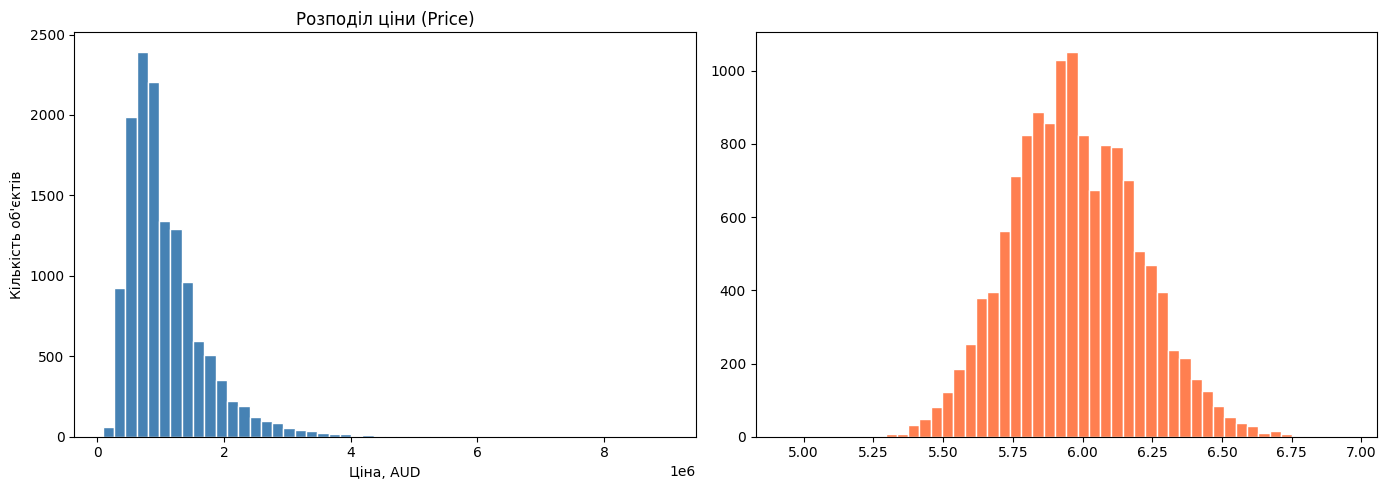

In [26]:
# Робимо графік розподілу ціни
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["Price"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Розподіл ціни (Price)")
axes[0].set_xlabel("Ціна, AUD")
axes[0].set_ylabel("Кількість об'єктів")
axes[1].hist(np.log10(df["Price"].dropna()), bins=50, color="coral", edgecolor="white")
plt.tight_layout()
plt.show()